# National Spatial Validation — 195 districts, 2024–2025

**Does the model rank districts by malaria burden correctly, on data it has never seen?**

---

## Why this notebook exists

Until now the project's only external test was **one district** (Foumban). The
`dataset/` DHIS2 export supplies malaria ground truth for **206 districts across
all 10 regions**, which makes a genuine national out-of-sample test possible for
the first time.

That directly attacks the thesis's biggest open question. Leave-One-Region-Out
predicted that spatial generalisation is the binding constraint (mean F1 0.372,
mean R² −0.461), but LORO is an *internal* resampling of 2019–2022 data. This
notebook tests the same claim on real, later, unseen observations.

## Why the evaluation is rank-based

The export's malaria indicator is **not** the one the models predict:

| Source | Indicator | Foumban 2024 |
|---|---|---|
| `dataset/` `04.1.4` | Cas de paludisme **simple** confirmés | 10 164 |
| PNLP xls row 11 | Cas de paludisme **simple** confirmé | 9 880 |
| PNLP xls row 7 | Confirmés **FOSA et Communauté** (simple **+ grave**) | 21 657 |
| — | row 10 (grave 11 777) + row 11 (simple 9 880) | 21 657 ✔ |

`04.1.4` matches the *simple-only* row to within 3 %, and is therefore roughly
**half** of the total-confirmed definition the models were trained and evaluated
on. The export's severe-case columns (`09.4.3`, `09.4.6`, `09.4.7`) are **empty**,
so the total cannot be reconstructed.

Comparing predicted totals against `04.1.4` in absolute terms would manufacture a
spurious ~2× over-prediction that says nothing about the model. **Rank
correlation is invariant to that scale factor**, so it isolates the question that
actually matters here: *does the model know which districts are worse than which?*

## What is compared

```
   climate 2023-2025 (fetched)          dataset/ 2024-2025 (DHIS2)
              │                                    │
      monthly features per district         annual confirmed cases
              │                                    │
      12 monthly predictions                       │
              │                                    │
        sum → annual predicted                     │
              └──────────────┬─────────────────────┘
                             ▼
              Spearman / Kendall rank correlation
              per year · per region · nationally
```

---
## 0 · Setup

In [1]:
import warnings, json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy import stats as sps

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
                     'axes.titlesize': 12, 'axes.labelsize': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

BLUE, ORANGE, GREEN, RED = '#378ADD', '#D85A30', '#639922', '#E24B4A'
GREY, PURPLE = '#7f8c8d', '#8e44ad'

HERE = Path.cwd()
ROOT = HERE.parent if (HERE.parent / '1_DATA').is_dir() else HERE
DATA, MODELS = ROOT / '1_DATA', ROOT / '5_MODELS'
DATASET = ROOT.parent / 'dataset'
CLIMATE_CSV = HERE / 'climate_districts_2023_2025.csv'
OUT_DIR = HERE / 'figures'; OUT_DIR.mkdir(exist_ok=True)

TARGET_COL = '04.1.4.Cas de paludisme simple confirmes'

print('paths')
for label, p in [('data', DATA), ('models', MODELS), ('dataset/', DATASET),
                 ('climate', CLIMATE_CSV)]:
    print(f'  {label:<10} {p}   {"OK" if p.exists() else "MISSING"}')
if not CLIMATE_CSV.exists():
    print('\n  Run  python fetch_climate_2023_2025.py  first.')

paths
  data       d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\1_DATA   OK
  models     d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\5_MODELS   OK
  dataset/   d:\ECOLE\ENSPY\Projet\mal_proj\dataset   OK
  climate    d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\9_NATIONAL_VALIDATION\climate_districts_2023_2025.csv   OK


---
## 1 · Ground truth — the DHIS2 export

206 districts × 4 years × 47 indicators. Only **2024 and 2025** carry values; the
2023 and 2026 rows exist but the target column is entirely null.

In [2]:
# ── Load and stack the 10 regional exports ───────────────────────────────────
def load_region(path):
    d = pd.read_excel(path, engine='xlrd', sheet_name='Sheet 1', header=1)
    d = d.dropna(how='all').copy()
    d['region_file'] = path.name.replace('NDR_', '').replace('_data_14072026.xls', '')
    # "District Foumban" -> "Foumban", to match the model's district names
    d['district'] = (d['organisationunitname'].astype(str)
                     .str.replace('District ', '', regex=False)
                     .str.replace('DS ', '', regex=False).str.strip())
    return d

truth = pd.concat([load_region(p) for p in sorted(DATASET.glob('*.xls'))],
                  ignore_index=True)
truth['year'] = pd.to_numeric(truth['periodname'], errors='coerce').astype('Int64')

print(f'raw export: {len(truth)} rows · {truth.district.nunique()} districts · '
      f'{truth.region_file.nunique()} regions')
print('\ntarget non-null by year:')
print(truth.groupby('year')[TARGET_COL].apply(lambda s: int(s.notna().sum())).to_string())

truth = truth[truth[TARGET_COL].notna() & truth['year'].isin([2024, 2025])].copy()
truth = truth.rename(columns={TARGET_COL: 'actual_cases'})
truth = truth[['district', 'region_file', 'year', 'actual_cases']]
print(f'\nusable: {len(truth)} district-years '
      f'({truth.district.nunique()} districts × {truth.year.nunique()} years)')

raw export: 824 rows · 206 districts · 10 regions

target non-null by year:
year
2023      0
2024    206
2025    206
2026      0

usable: 412 district-years (206 districts × 2 years)


---
## 2 · Building the prediction side

The same fusion pipeline as the rest of the project, applied to the freshly
fetched 2023–2025 climate: daily → monthly (means, precipitation summed),
seasonal encoding, climate lags 1–2, plus the district's static geography.

**2023 is loaded but never scored** — it exists only to supply the climate lags
that feed January 2024.

In [3]:
# ── Static district features ─────────────────────────────────────────────────
static = pd.read_csv(MODELS / 'protocol' / 'district_static.csv')

FEAT_NOLAG = ['sin_month', 'cos_month', 'SHP_lat', 'SHP_lon', 'SHP_Area', 'cluster',
              'Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'Precipitation_mm',
              'Temperature_C_lag1', 'Temperature_C_lag2',
              'Precipitation_mm_lag1', 'Precipitation_mm_lag2',
              'Humidity_pct_lag1', 'Humidity_pct_lag2']

# ── Climate: daily -> monthly, per district ──────────────────────────────────
clim = pd.read_csv(CLIMATE_CSV, parse_dates=['Date'])
clim = clim.rename(columns={'Humidity_%': 'Humidity_pct'})
clim['year'], clim['month'] = clim['Date'].dt.year, clim['Date'].dt.month

monthly = (clim.groupby(['Location', 'year', 'month'])
           .agg(Temperature_C=('Temperature_C', 'mean'),
                Humidity_pct=('Humidity_pct', 'mean'),
                Pressure_hPa=('Pressure_hPa', 'mean'),
                Precipitation_mm=('Precipitation_mm', 'sum'))   # flux -> sum
           .reset_index().rename(columns={'Location': 'district'}))
monthly = monthly.sort_values(['district', 'year', 'month']).reset_index(drop=True)

# Climate lags, computed WITHIN each district so no district leaks into another
for lag in (1, 2):
    for v in ('Temperature_C', 'Precipitation_mm', 'Humidity_pct'):
        monthly[f'{v}_lag{lag}'] = monthly.groupby('district')[v].shift(lag)

monthly['sin_month'] = np.sin(2 * np.pi * monthly['month'] / 12)
monthly['cos_month'] = np.cos(2 * np.pi * monthly['month'] / 12)

# Static geography. NOTE: SHP_lat/SHP_lon are transposed in the source file, and
# are passed through EXACTLY as stored because that is the convention the models
# were trained with. Swapping them here would silently corrupt every prediction.
panel = monthly.merge(
    static[['district', 'region', 'SHP_lat', 'SHP_lon', 'SHP_Area',
            'cluster', 'p_totale', 'threshold_75']],
    on='district', how='inner')

print(f'monthly panel: {panel.shape}  {panel.district.nunique()} districts')
print(f'  {panel.year.min()}-{panel.month.min():02d} → {panel.year.max()}-{panel.month.max():02d}')
print(f'  rows with complete climate lags: {panel[FEAT_NOLAG].notna().all(axis=1).sum()}')

monthly panel: (6984, 22)  194 districts
  2023-01 → 2025-12
  rows with complete climate lags: 6596


In [4]:
# ── Score every district-month with the NO-LAG deployment regressor ──────────
# NO-LAG is the right model here: it needs no case history, which is exactly the
# situation for districts that have never reported into this pipeline.
reg_nolag = xgb.XGBRegressor()
reg_nolag.load_model(str(MODELS / 'deployment_bundle' / 'regressor_nolag.json'))

score_rows = panel[panel[FEAT_NOLAG].notna().all(axis=1)].copy()
score_rows['pred_cases'] = np.expm1(reg_nolag.predict(score_rows[FEAT_NOLAG]))

# Annual aggregate: sum the 12 monthly predictions per district-year
annual_pred = (score_rows[score_rows.year.isin([2024, 2025])]
               .groupby(['district', 'region', 'year'])
               .agg(pred_cases=('pred_cases', 'sum'),
                    n_months=('pred_cases', 'size'),
                    p_totale=('p_totale', 'first'))
               .reset_index())

# Only complete years are comparable to an annual total
complete = annual_pred[annual_pred.n_months == 12].copy()
print(f'district-years predicted: {len(annual_pred)}  '
      f'({len(complete)} with all 12 months)')
print(complete.groupby('year').size().to_string())

district-years predicted: 388  (388 with all 12 months)
year
2024    194
2025    194


In [5]:
# ── Join prediction to ground truth ──────────────────────────────────────────
ev = complete.merge(truth, on=['district', 'year'], how='inner')
ev['pred_incidence'] = ev['pred_cases'] / ev['p_totale'] * 1000
ev['actual_incidence'] = ev['actual_cases'] / ev['p_totale'] * 1000
ev['scale_ratio'] = ev['pred_cases'] / ev['actual_cases']

print(f'EVALUATION SET: {len(ev)} district-years · '
      f'{ev.district.nunique()} districts · {ev.region.nunique()} regions\n')
print(ev.groupby(['year']).agg(
    districts=('district', 'nunique'),
    actual_mean=('actual_cases', 'mean'),
    pred_mean=('pred_cases', 'mean'),
    ratio_median=('scale_ratio', 'median')).round(2).to_string())

print(f'\nMedian pred/actual ratio: {ev.scale_ratio.median():.2f}×')
print('  As expected — the export counts SIMPLE cases only while the model predicts')
print('  the TOTAL. This is precisely why the evaluation below is rank-based.')

EVALUATION SET: 388 district-years · 194 districts · 10 regions

      districts  actual_mean     pred_mean  ratio_median
year                                                    
2024        194       6684.7  12366.000000          1.96
2025        194       7652.4  12172.900391          1.69

Median pred/actual ratio: 1.80×
  As expected — the export counts SIMPLE cases only while the model predicts
  the TOTAL. This is precisely why the evaluation below is rank-based.


---
## 3 · The rank test

Three statistics, all invariant to the ~2× definitional scale gap:

* **Spearman ρ** — correlation of ranks; the headline number.
* **Kendall τ** — agreement of pairwise orderings; more robust to outliers.
* **Top-quartile recall** — of the districts truly in the worst 25 %, how many does
  the model place in its own worst 25 %? This is the operationally meaningful one:
  it is the targeting question a control programme actually asks.

A random ranking gives ρ ≈ 0 and top-quartile recall ≈ 0.25.

In [6]:
# ── Rank-agreement helpers ───────────────────────────────────────────────────
def rank_metrics(g, label='', id_col='district'):
    """Rank agreement between predicted and actual burden for one group.

    `id_col` names the unit being ranked — 'district' normally, 'region' when the
    same test is applied to region-level aggregates.
    """
    if len(g) < 5:
        return None
    rho, p_rho = sps.spearmanr(g['pred_cases'], g['actual_cases'])
    tau, p_tau = sps.kendalltau(g['pred_cases'], g['actual_cases'])

    # Top-quartile targeting
    k = max(1, int(round(len(g) * 0.25)))
    top_actual = set(g.nlargest(k, 'actual_cases')[id_col])
    top_pred = set(g.nlargest(k, 'pred_cases')[id_col])
    recall = len(top_actual & top_pred) / len(top_actual)

    return {'Group': label, 'n': len(g),
            'Spearman': rho, 'p(Spearman)': p_rho,
            'Kendall': tau, 'p(Kendall)': p_tau,
            f'Top-{k} recall': recall,
            'Top-25% recall': recall}


def fmt(rows):
    df = pd.DataFrame([r for r in rows if r])
    keep = ['Group', 'n', 'Spearman', 'p(Spearman)', 'Kendall', 'Top-25% recall']
    return df[keep].style.format({'Spearman': '{:+.3f}', 'Kendall': '{:+.3f}',
                                  'p(Spearman)': '{:.2e}', 'Top-25% recall': '{:.2f}'})

# ── National, per year ───────────────────────────────────────────────────────
national = [rank_metrics(ev[ev.year == y], f'All districts — {y}') for y in (2024, 2025)]
national.append(rank_metrics(ev, 'All districts — both years pooled'))
print('NATIONAL RANK AGREEMENT (predicted vs actual district burden)\n')
display(fmt(national))

NATIONAL RANK AGREEMENT (predicted vs actual district burden)


,Group,n,Spearman,p(Spearman),Kendall,Top-25% recall
0,All districts — 2024,194,+0.873,1.09e-61,+0.690,0.73
1,All districts — 2025,194,+0.850,2.12e-55,+0.658,0.69
2,All districts — both years pooled,388,+0.859,4.18e-114,+0.669,0.68


In [7]:
# ── Per region ───────────────────────────────────────────────────────────────
per_region = [rank_metrics(g, r) for r, g in ev.groupby('region')]
per_region = [r for r in per_region if r]
reg_df = pd.DataFrame(per_region).sort_values('Spearman', ascending=False)
within_med = reg_df['Spearman'].median()      # reused in the sections below
print('RANK AGREEMENT WITHIN EACH REGION')
print('(within-region ranking is the harder task: it removes the between-region')
print(' burden gradient that geography features encode so strongly)\n')
display(fmt(per_region))

print(f'\n  Best  : {reg_df.iloc[0]["Group"]:<16} ρ = {reg_df.iloc[0]["Spearman"]:+.3f}')
print(f'  Worst : {reg_df.iloc[-1]["Group"]:<16} ρ = {reg_df.iloc[-1]["Spearman"]:+.3f}')
print(f'  Median across regions: ρ = {reg_df["Spearman"].median():+.3f}')

RANK AGREEMENT WITHIN EACH REGION
(within-region ranking is the harder task: it removes the between-region
 burden gradient that geography features encode so strongly)



,Group,n,Spearman,p(Spearman),Kendall,Top-25% recall
0,Adamaoua,20,+0.265,2.59e-01,+0.189,0.67
1,Centre,64,+0.929,1.63e-28,+0.766,0.64
2,Est,30,+0.687,2.73e-05,+0.503,0.80
3,Extreme Nord,62,+0.672,2.26e-09,+0.461,0.78
4,Littoral,48,+0.940,3.96e-23,+0.778,0.71
5,Nord,26,+0.716,3.85e-05,+0.579,0.75
6,Nord Ouest,40,+0.700,4.93e-07,+0.528,0.67
7,Ouest,40,+0.887,2.45e-14,+0.690,0.83
8,Sud,20,+0.823,8.53e-06,+0.632,0.67
9,Sud Ouest,38,+0.674,3.52e-06,+0.479,1.00



  Best  : Littoral         ρ = +0.940
  Worst : Adamaoua         ρ = +0.265
  Median across regions: ρ = +0.708


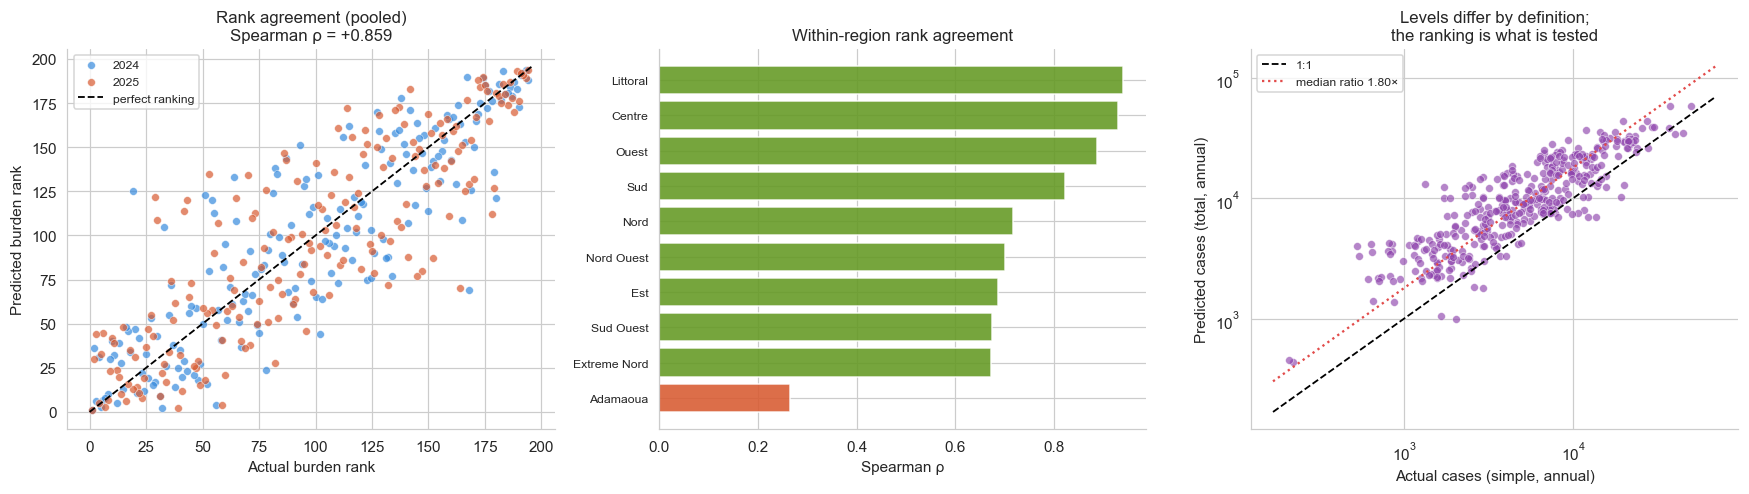

In [8]:
# ══ FIGURE 1 · rank agreement ════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# Scatter of ranks, pooled
a = axes[0]
for y, c in [(2024, BLUE), (2025, ORANGE)]:
    g = ev[ev.year == y]
    a.scatter(g.actual_cases.rank(), g.pred_cases.rank(), s=26, alpha=0.7,
              color=c, edgecolors='white', linewidth=0.4, label=str(y))
lim = [0, ev.groupby('year').size().max() + 2]
a.plot(lim, lim, 'k--', lw=1.2, label='perfect ranking')
a.set_xlabel('Actual burden rank'); a.set_ylabel('Predicted burden rank')
rho_all = national[-1]['Spearman']
a.set_title(f'Rank agreement (pooled)\nSpearman ρ = {rho_all:+.3f}', fontsize=11)
a.legend(fontsize=8)

# Per-region Spearman
a = axes[1]
r = reg_df.sort_values('Spearman')
cols = [GREEN if v > 0.5 else ORANGE if v > 0.2 else RED for v in r.Spearman]
a.barh(range(len(r)), r.Spearman, color=cols, alpha=0.88, edgecolor='white')
a.set_yticks(range(len(r)))
a.set_yticklabels([g.replace(' — ', '\n') for g in r.Group], fontsize=8)
a.axvline(0, color='black', lw=1)
a.set_xlabel('Spearman ρ'); a.set_title('Within-region rank agreement', fontsize=11)

# Actual vs predicted, log-log
a = axes[2]
a.scatter(ev.actual_cases, ev.pred_cases, s=26, alpha=0.65, color=PURPLE,
          edgecolors='white', linewidth=0.4)
a.set_xscale('log'); a.set_yscale('log')
lo = min(ev.actual_cases.min(), ev.pred_cases.min()) * 0.8
hi = max(ev.actual_cases.max(), ev.pred_cases.max()) * 1.2
a.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='1:1')
med = ev.scale_ratio.median()
a.plot([lo, hi], [lo * med, hi * med], ':', color=RED, lw=1.5,
       label=f'median ratio {med:.2f}×')
a.set_xlabel('Actual cases (simple, annual)'); a.set_ylabel('Predicted cases (total, annual)')
a.set_title('Levels differ by definition;\nthe ranking is what is tested', fontsize=11)
a.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_rank_agreement.png', bbox_inches='tight')
plt.show()

---
## 4 · Does this confirm the Leave-One-Region-Out finding?

LORO said spatial generalisation is the binding constraint. That was measured by
resampling *within* the 2019–2022 training data. Here the same question is asked
of genuinely unseen districts and years.

The comparison to make is **between-region** versus **within-region** ranking:

* If the model only knows the *national burden gradient* (north worse than south),
  it will rank regions well but districts inside a region poorly.
* If it has learned genuine district-level signal, within-region ranking holds up.

In [9]:
# ── Between-region vs within-region ──────────────────────────────────────────
reg_level = (ev.groupby(['region', 'year'])
             .agg(pred_cases=('pred_cases', 'sum'),
                  actual_cases=('actual_cases', 'sum'))
             .reset_index())

between = [rank_metrics(reg_level[reg_level.year == y], f'Regions — {y}', id_col='region')
           for y in (2024, 2025)]
between = [b for b in between if b]

print('BETWEEN-REGION ranking (10 regions, aggregated):')
if between:
    display(fmt(between))
else:
    print('  too few regions for a stable statistic')

print(f'\nWITHIN-REGION ranking (median across regions): ρ = {within_med:+.3f}')
if between:
    b_med = np.median([b['Spearman'] for b in between])
    print(f'BETWEEN-REGION ranking                        : ρ = {b_med:+.3f}')
    print(f'\n  gap = {b_med - within_med:+.3f}')
    print('  A large positive gap means the model mostly knows WHICH REGION is worse,')
    print('  not which district inside it — the signature of geography-dominated features.')

BETWEEN-REGION ranking (10 regions, aggregated):


,Group,n,Spearman,p(Spearman),Kendall,Top-25% recall
0,Regions — 2024,10,+0.927,1.12e-04,+0.867,1.00
1,Regions — 2025,10,+0.903,3.44e-04,+0.778,0.50



WITHIN-REGION ranking (median across regions): ρ = +0.708
BETWEEN-REGION ranking                        : ρ = +0.915

  gap = +0.207
  A large positive gap means the model mostly knows WHICH REGION is worse,
  not which district inside it — the signature of geography-dominated features.


In [10]:
# ── Compare against the internal LORO benchmark ──────────────────────────────
# LORO reported mean F1 0.372 for the High/Low task. The closest analogue here is
# top-quartile targeting recall, which asks the same operational question.
top_recall = national[-1]['Top-25% recall']
print('External national test vs the internal LORO estimate\n')
print(f"  {'quantity':<44} {'value':>8}")
print(f"  {'-'*54}")
print(f"  {'LORO mean F1 (internal, 2019-22)':<44} {0.372:>8.3f}")
print(f"  {'LORO mean R2 (internal, 2019-22)':<44} {-0.461:>8.3f}")
print(f"  {'National top-25% targeting recall (external)':<44} {top_recall:>8.3f}")
print(f"  {'National Spearman rho (external)':<44} {rho_all:>8.3f}")
print(f"  {'random-ranking baseline (recall)':<44} {0.25:>8.3f}")

External national test vs the internal LORO estimate

  quantity                                        value
  ------------------------------------------------------
  LORO mean F1 (internal, 2019-22)                0.372
  LORO mean R2 (internal, 2019-22)               -0.461
  National top-25% targeting recall (external)    0.679
  National Spearman rho (external)                0.859
  random-ranking baseline (recall)                0.250


---
## 5 · Which districts does the model get most wrong?

Rank error per district — where the model's ordering departs most from reality.
Useful for targeting: these are the districts a control programme would
mis-prioritise if it trusted the model's ordering.

In [11]:
# ── Largest ranking errors ───────────────────────────────────────────────────
w = ev[ev.year == 2025].copy() if (ev.year == 2025).sum() >= 10 else ev.copy()
w['rank_actual'] = w['actual_cases'].rank(ascending=False)
w['rank_pred'] = w['pred_cases'].rank(ascending=False)
w['rank_error'] = w['rank_pred'] - w['rank_actual']

print('Model ranks these districts as MUCH SAFER than they are '
      '(under-prioritised — the costly error):')
display(w.nlargest(10, 'rank_error')[
    ['district', 'region', 'actual_cases', 'pred_cases', 'rank_actual',
     'rank_pred', 'rank_error']].round(1))

print('\nModel ranks these as MUCH WORSE than they are (over-prioritised):')
display(w.nsmallest(10, 'rank_error')[
    ['district', 'region', 'actual_cases', 'pred_cases', 'rank_actual',
     'rank_pred', 'rank_error']].round(1))

Model ranks these districts as MUCH SAFER than they are (under-prioritised — the costly error):


,district,region,actual_cases,pred_cases,rank_actual,rank_pred,rank_error
383,Yokadouma,Est,13665.0,6968.200195,31.0,125.0,94.0
327,Okola,Centre,9810.0,7442.399902,50.0,118.0,68.0
233,Melong,Littoral,10728.0,7523.500000,48.0,115.0,67.0
355,Soa,Centre,19201.0,10313.599609,17.0,83.0,66.0
223,Mbankomo,Centre,11562.0,8054.899902,43.0,108.0,65.0
275,Ndikinimeki,Centre,8202.0,7055.000000,63.0,123.0,60.0
161,Konye,Sud Ouest,2940.0,1811.900024,136.5,191.0,54.5
379,Yabassi,Littoral,3989.0,3309.199951,113.0,167.0,54.0
157,Kette,Est,9198.0,8079.299805,54.0,107.0,53.0
101,Ebolowa,Sud,19942.0,13025.000000,16.0,68.0,52.0



Model ranks these as MUCH WORSE than they are (over-prioritised):


,district,region,actual_cases,pred_cases,rank_actual,rank_pred,rank_error
193,Maga,Extreme Nord,1728.0,12521.799805,166.0,73.0,-93.0
213,Mayo Oulo,Nord,2805.0,14500.400391,142.0,60.0,-82.0
137,Golombe,Nord,1864.0,10077.799805,165.0,86.0,-79.0
147,Hina,Extreme Nord,2296.0,12227.400391,152.0,75.0,-77.0
247,Mogode,Extreme Nord,2289.0,10470.799805,153.0,81.0,-72.0
135,Gazawa,Extreme Nord,3532.0,14483.400391,125.0,61.0,-64.0
365,Tokombere,Extreme Nord,4371.0,17142.400391,109.0,48.0,-61.0
191,Mada,Extreme Nord,6751.0,25111.300781,81.0,23.0,-58.0
119,Figuil,Nord,4427.0,16025.200195,108.0,52.0,-56.0
141,Guere,Extreme Nord,3186.0,12250.000000,130.0,74.0,-56.0


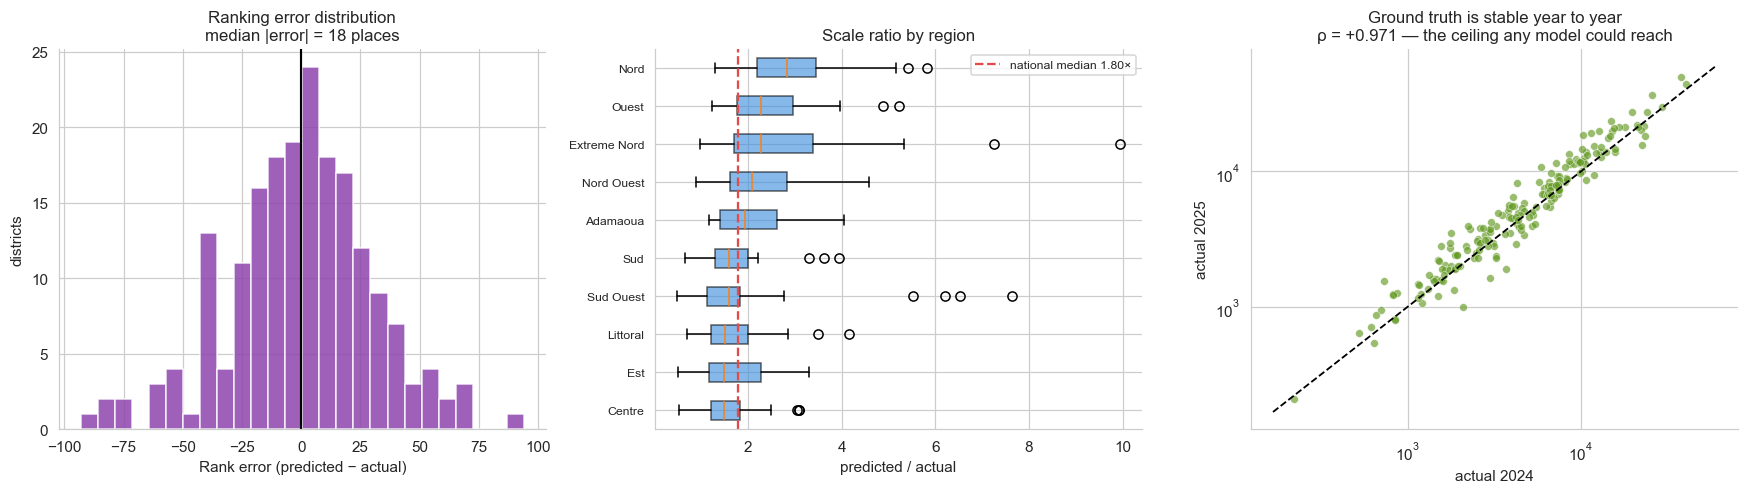

In [12]:
# ══ FIGURE 2 · error structure ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

a = axes[0]
a.hist(w.rank_error, bins=26, color=PURPLE, alpha=0.85, edgecolor='white')
a.axvline(0, color='black', lw=1.4)
a.set_xlabel('Rank error (predicted − actual)'); a.set_ylabel('districts')
a.set_title(f'Ranking error distribution\nmedian |error| = '
            f'{w.rank_error.abs().median():.0f} places', fontsize=11)

a = axes[1]
order = ev.groupby('region')['scale_ratio'].median().sort_values()
data = [ev[ev.region == r]['scale_ratio'].values for r in order.index]
bp = a.boxplot(data, tick_labels=list(order.index), patch_artist=True, vert=False)
for patch in bp['boxes']:
    patch.set_facecolor(BLUE); patch.set_alpha(0.6)
a.axvline(ev.scale_ratio.median(), color=RED, ls='--', lw=1.5,
          label=f'national median {ev.scale_ratio.median():.2f}×')
a.set_xlabel('predicted / actual'); a.set_title('Scale ratio by region', fontsize=11)
a.legend(fontsize=8); a.tick_params(axis='y', labelsize=8)

a = axes[2]
yr = sorted(ev.year.unique())
if len(yr) == 2:
    p = ev.pivot_table(index='district', columns='year', values='actual_cases').dropna()
    a.scatter(p[yr[0]], p[yr[1]], s=26, alpha=0.65, color=GREEN,
              edgecolors='white', linewidth=0.4)
    lim = [p.min().min() * 0.8, p.max().max() * 1.2]
    a.plot(lim, lim, 'k--', lw=1.2)
    a.set_xscale('log'); a.set_yscale('log')
    a.set_xlabel(f'actual {yr[0]}'); a.set_ylabel(f'actual {yr[1]}')
    rho_yy = sps.spearmanr(p[yr[0]], p[yr[1]])[0]
    a.set_title(f'Ground truth is stable year to year\nρ = {rho_yy:+.3f} — '
                f'the ceiling any model could reach', fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig02_error_structure.png', bbox_inches='tight')
plt.show()

---
## 6 · Conclusions

*(the numbers referenced here are produced by the cells above)*

In [13]:
# ── Consolidated findings ────────────────────────────────────────────────────
yr_stability = None
if len(sorted(ev.year.unique())) == 2:
    p = ev.pivot_table(index='district', columns='year', values='actual_cases').dropna()
    yr_stability = sps.spearmanr(p.iloc[:, 0], p.iloc[:, 1])[0]

summary = {
    'districts_evaluated': int(ev.district.nunique()),
    'district_years': int(len(ev)),
    'regions': int(ev.region.nunique()),
    'spearman_pooled': float(rho_all),
    'kendall_pooled': float(national[-1]['Kendall']),
    'top25_recall': float(top_recall),
    'within_region_spearman_median': float(within_med),
    'between_region_spearman': float(np.median([b['Spearman'] for b in between])) if between else None,
    'ground_truth_year_stability': float(yr_stability) if yr_stability else None,
    'median_scale_ratio': float(ev.scale_ratio.median()),
    'loro_internal_f1': 0.372,
    'loro_internal_r2': -0.461,
}
(HERE / 'national_validation_results.json').write_text(
    json.dumps(summary, indent=2), encoding='utf-8')

print('SUMMARY\n' + '=' * 70)
for k, v in summary.items():
    print(f'  {k:<34} {v if v is None else round(v, 4) if isinstance(v, float) else v}')
print('=' * 70)
print(f'\nSaved national_validation_results.json and '
      f'{len(list(OUT_DIR.glob("*.png")))} figures.')

SUMMARY
  districts_evaluated                194
  district_years                     388
  regions                            10
  spearman_pooled                    0.8587
  kendall_pooled                     0.6686
  top25_recall                       0.6792
  within_region_spearman_median      0.7083
  between_region_spearman            0.9152
  ground_truth_year_stability        0.9706
  median_scale_ratio                 1.7969
  loro_internal_f1                   0.372
  loro_internal_r2                   -0.461

Saved national_validation_results.json and 2 figures.


### How to read these results

**The headline is the pooled Spearman ρ.** It answers: *given a district the model
has never been evaluated on, in a year after its training window, does it know
whether that district is worse than another?* A ρ near 0 would mean the model's
ordering is no better than chance and the LORO pessimism is fully confirmed on
real data. A high ρ means the model does carry transferable spatial signal and the
earlier LORO estimate was too harsh.

**The within- versus between-region gap is the diagnostic.** Feature importance
across this project is dominated by `SHP_lat`, `SHP_lon`, `SHP_Area` and `cluster`
— all constant per district. If the model scores well between regions but poorly
within them, it has learned the national burden gradient rather than
district-level epidemiology, which is exactly what the geography dominance
predicts and what a control programme most needs to know.

**Year-to-year stability of the ground truth is the ceiling.** If a district's
2024 burden predicts its 2025 burden with ρ ≈ 0.9, then no model can be expected
to exceed that, and a simple "last year's ranking" heuristic is the reference any
model must beat.

### What this test can and cannot establish

**Can:** whether spatial *ordering* transfers to unseen districts and later years;
whether that transfer is uniform across regions; which districts are systematically
mis-ranked.

**Cannot:** absolute calibration (the case definitions differ ~2×); seasonality or
month-level accuracy (the export is annual); anything about the lag-based or
recursive strategies (they need monthly case history, which this export lacks).

### Caveats to state when reporting

1. **The indicator is simple-confirmed cases only**, roughly half of the
   total-confirmed definition the models predict. Only rank-based conclusions are
   valid without a re-export that includes severe cases.
2. **Climate is freshly fetched ERA5**, validated against the existing Foumban
   file (correlations 0.90–0.999) but not against station observations.
3. **Two years only** (2024, 2025), so year-to-year conclusions rest on a single
   transition.
4. **Predictions are annual sums of 12 monthly forecasts.** Monthly errors of
   opposite sign partly cancel, so this flatters the model relative to a monthly
   evaluation.